In [1]:
!python --version

Python 3.10.20


In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pickle
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import seaborn as sns
from sklearn.manifold import MDS
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from allensdk.brain_observatory.ecephys.ecephys_project_api import EcephysProjectWarehouseApi
from allensdk.brain_observatory.ecephys.ecephys_project_api.rma_engine import RmaEngine
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [3]:
data_directory = "./ecephys_cache_dir"
manifest_path = os.path.join(data_directory, "manifest.json")

cache = EcephysProjectCache(
    manifest=manifest_path,
    fetch_api=EcephysProjectWarehouseApi(
        RmaEngine(
            scheme="http",
            host="api.brain-map.org",
            timeout=5 * 3600,
        )
    ),
)

SESSION_ID = 757216464
session = cache.get_session_data(SESSION_ID)

C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [4]:
session.metadata

C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.

{'specimen_name': 'C57BL/6J-412794',
 'session_type': 'brain_observatory_1.1',
 'full_genotype': 'wt/wt',
 'sex': 'M',
 'age_in_days': 105.0,
 'rig_equipment_name': 'NP.1',
 'num_units': 959,
 'num_channels': 2225,
 'num_probes': 6,
 'num_stimulus_presentations': 70390,
 'session_start_time': datetime.datetime(2018, 10, 26, 12, 55, 34, tzinfo=tzoffset(None, -25200)),
 'ecephys_session_id': 757216464,
 'structure_acronyms': [nan,
  'PO',
  'LP',
  'LGd',
  'HPF',
  'CA3',
  'DG',
  'CA1',
  'VISal',
  'VISrl',
  'VISl',
  'TH',
  'LGv',
  'MRN',
  'MB',
  'APN',
  'NOT',
  'VISam',
  'VIS',
  'Eth',
  'MGm',
  'SGN',
  'ProS',
  'SUB',
  'VISp'],
 'stimulus_names': ['spontaneous',
  'gabors',
  'flashes',
  'drifting_gratings',
  'natural_movie_three',
  'natural_movie_one',
  'static_gratings',
  'natural_scenes']}

In [5]:
session.structurewise_unit_counts

LP       114
CA1      112
VISp      85
PO        80
VISam     64
VIS       60
VISal     53
VISl      53
APN       47
SGN       45
Eth       42
DG        42
SUB       41
VISrl     37
TH        18
MGm       16
CA3       13
LGv       11
ProS       7
LGd        6
NOT        5
MRN        5
MB         3
Name: ecephys_structure_acronym, dtype: int64

In [6]:
presentations = session.stimulus_presentations
mask = (presentations["stimulus_name"] == "natural_scenes") & (presentations["frame"] != -1)
natural_scene_presentations = presentations.loc[mask]

In [7]:
natural_scene_presentations["frame"].unique()

array([52.0, 55.0, 14.0, 101.0, 92.0, 100.0, 95.0, 106.0, 57.0, 30.0,
       59.0, 2.0, 45.0, 61.0, 49.0, 15.0, 113.0, 75.0, 23.0, 47.0, 90.0,
       98.0, 96.0, 26.0, 81.0, 62.0, 86.0, 68.0, 42.0, 39.0, 110.0, 19.0,
       12.0, 48.0, 87.0, 111.0, 88.0, 91.0, 89.0, 64.0, 102.0, 13.0,
       109.0, 69.0, 71.0, 83.0, 33.0, 77.0, 8.0, 10.0, 76.0, 6.0, 112.0,
       66.0, 72.0, 94.0, 85.0, 24.0, 36.0, 53.0, 117.0, 79.0, 4.0, 7.0,
       99.0, 65.0, 105.0, 104.0, 114.0, 40.0, 41.0, 78.0, 32.0, 27.0,
       20.0, 84.0, 38.0, 28.0, 50.0, 0.0, 17.0, 60.0, 54.0, 63.0, 74.0,
       56.0, 116.0, 73.0, 43.0, 70.0, 108.0, 5.0, 11.0, 31.0, 34.0, 16.0,
       58.0, 80.0, 46.0, 22.0, 115.0, 29.0, 103.0, 97.0, 3.0, 18.0, 35.0,
       1.0, 82.0, 107.0, 37.0, 9.0, 93.0, 25.0, 67.0, 51.0, 21.0, 44.0],
      dtype=object)

In [8]:
labels = sorted(int(f) for f in natural_scene_presentations["frame"].unique())
len(labels)

118

In [9]:
IMAGE_DIR = os.path.join(data_directory, "natural_scene_templates")
os.makedirs(IMAGE_DIR, exist_ok=True)

image_names = []
for frame in labels:
    img_arr = cache.get_natural_scene_template(frame)
    img_name = "natural_scene_" + str(frame)
    Image.fromarray(img_arr).save(os.path.join(IMAGE_DIR, img_name + ".png"))
    image_names.append(img_name)

In [10]:
labels_df = pd.DataFrame({
    "image_name": image_names,
    "frame": labels,
})

labels_df

,image_name,frame
0,natural_scene_0,0
1,natural_scene_1,1
2,natural_scene_2,2
3,natural_scene_3,3
4,natural_scene_4,4
...,...,...
113,natural_scene_113,113
114,natural_scene_114,114
115,natural_scene_115,115
116,natural_scene_116,116


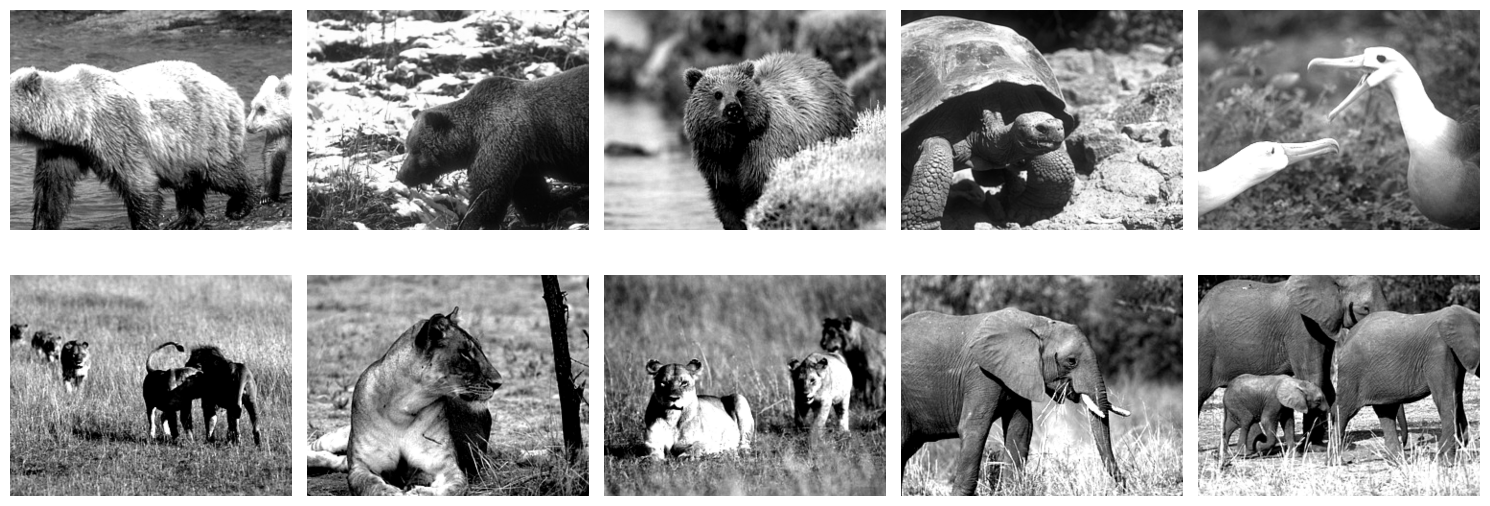

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_frames = labels[:10]

for ax, frame in zip(axes.flat, sample_frames):
    img = cache.get_natural_scene_template(frame)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
model.eval()

print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [13]:
activations = {}

def make_hook(layer_name):
    def hook(module, input, output):
        activations[layer_name] = output.detach().cpu().numpy().reshape(output.shape[0], -1)
    return hook

In [14]:
hooks = []
layer_names = []

for idx, layer in enumerate(model.features):
    if isinstance(layer, nn.ReLU):
        name = f"features_{idx}_relu"
        hooks.append(layer.register_forward_hook(make_hook(name)))
        layer_names.append(name)


for idx, layer in enumerate(model.classifier):
    if isinstance(layer, nn.Linear) and idx == 6:
        name = f"classifier_{idx}_linear_output"
        hooks.append(layer.register_forward_hook(make_hook(name)))
        layer_names.append(name)
    elif isinstance(layer, nn.ReLU):
        name = f"classifier_{idx}_relu"
        hooks.append(layer.register_forward_hook(make_hook(name)))
        layer_names.append(name)


for n in layer_names:
    print(n)

features_1_relu
features_4_relu
features_7_relu
features_9_relu
features_11_relu
classifier_2_relu
classifier_5_relu
classifier_6_linear_output


In [15]:
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def preprocess_image(img_arr):
    arr = np.asarray(img_arr)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        arr = arr - arr.min()
        if arr.max() > 0:
            arr = arr / arr.max()
        arr = (arr * 255).astype(np.uint8)
    return preprocess(arr)

In [16]:
data_directory = "./ecephys_cache_dir"
IMAGE_DIR = os.path.join(data_directory, "natural_scene_templates")
labels_df = pd.read_csv("image_labels.csv")

images = {
    name: np.array(Image.open(os.path.join(IMAGE_DIR, f"{name}.png")))
    for name in image_names
}

In [17]:
images["natural_scene_1"]

array([[64, 64, 64, ..., 66, 84, 84],
       [64, 64, 64, ..., 66, 84, 84],
       [64, 64, 64, ..., 66, 84, 84],
       ...,
       [48, 48, 48, ..., 74, 75, 75],
       [56, 56, 56, ..., 30, 35, 35],
       [56, 56, 56, ..., 30, 35, 35]], dtype=uint8)

In [18]:
all_layer_activations = {name: [] for name in layer_names}

with torch.no_grad():
    for name in image_names:
        img_tensor = preprocess_image(images[name]).unsqueeze(0)
        model(img_tensor)
        for layer_name in layer_names:
            all_layer_activations[layer_name].append(activations[layer_name][0])

final_activations = {
    name: np.stack(all_layer_activations[name], axis=0)
    for name in layer_names
}

In [19]:
for _, arr in final_activations.items():
    print(arr.shape)

(118, 193600)
(118, 139968)
(118, 64896)
(118, 43264)
(118, 43264)
(118, 4096)
(118, 4096)
(118, 1000)


In [20]:
AREAS = ["LGd", "VISp", "VISrl", "VISam"]

In [21]:
units = session.units

In [22]:
len(units[units["ecephys_structure_acronym"] == "LGd"])

6

In [23]:
units[units["ecephys_structure_acronym"] == "LGd"].index.values

array([951818426, 951818410, 951818440, 951818466, 951818461, 951818495],
      dtype=int64)

In [24]:
image_name_to_frame = dict(zip(labels_df["image_name"], labels_df["frame"].astype(float)))

In [25]:
units_by_area = {}
for area in AREAS:
    area_units = units[units["ecephys_structure_acronym"] == area]
    units_by_area[area] = area_units.index.values
    print(f"{area}: {len(units_by_area[area])}")

LGd: 6
VISp: 85
VISrl: 37
VISam: 64


In [26]:
presentations = session.stimulus_presentations
mask = (presentations["stimulus_name"] == "natural_scenes") & (presentations["frame"] != -1)
natural_scene_presentations = presentations.loc[mask]
print(len(natural_scene_presentations))

missing = set(image_name_to_frame.values()) - set(natural_scene_presentations["frame"].unique())
print(len(missing))

5900
0


In [27]:
win_start = 0.05
win_end = 0.20
bin_edges = np.array([win_start, win_end])
bin_edges

array([0.05, 0.2 ])

In [28]:
window_duration = win_end - win_start

In [29]:
window_duration

0.15000000000000002

In [30]:
neural_data = {"image_names": image_names, "areas": {}}

for area in AREAS:
    unit_ids = units_by_area[area]
    if len(unit_ids) == 0:
        print(f"Skipping {area}")
        continue

    n_images = len(image_names)
    n_units = len(unit_ids)
    response_matrix = np.zeros((n_images, n_units))

    for i, img_name in enumerate(image_names):
        frame = image_name_to_frame[img_name]
        img_presentations = natural_scene_presentations[natural_scene_presentations["frame"] == frame]
        presentation_ids = img_presentations.index.values

        if len(presentation_ids) == 0:
            print(f"{img_name} has 0 presentations")
            continue

        spike_counts = session.presentationwise_spike_counts(bin_edges=bin_edges, stimulus_presentation_ids=presentation_ids, unit_ids=unit_ids)
        counts = spike_counts.sum(dim="time_relative_to_stimulus_onset").values
        firing_rates_hz = counts / window_duration
        mean_rate_per_unit = firing_rates_hz.mean(axis=0)

        response_matrix[i, :] = mean_rate_per_unit

    neural_data["areas"][area] = response_matrix
    print(f"{area}- response matri {response_matrix.shape}")

LGd- response matri (118, 6)
VISp- response matri (118, 85)
VISrl- response matri (118, 37)
VISam- response matri (118, 64)


In [31]:
with open("alexnet_activations.pkl", "wb") as f:
    pickle.dump({
        "image_names": image_names,
        "activations": final_activations,
    }, f)

with open("neural_data.pkl", "wb") as f:
    pickle.dump(neural_data, f)

In [32]:
with open("alexnet_activations.pkl", "rb") as f:
    alexnet_data = pickle.load(f)

with open("neural_data.pkl", "rb") as f:
    neural_data = pickle.load(f)

In [33]:
def rdm(response_matrix):
    variances = response_matrix.var(axis=0)
    clean = response_matrix[:, variances > 1e-12]
    distances = pdist(clean, metric="correlation")
    return squareform(distances)

In [34]:
layer_rdms = {name: rdm(alexnet_data["activations"][name]) for name in layer_names}

In [35]:
area_rdms = {name: rdm(neural_data["areas"][name]) for name in AREAS}

In [36]:
for name, rdm in list(layer_rdms.items()):
    print(rdm.shape)
for name, rdm in area_rdms.items():
    print(rdm.shape)

(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)
(118, 118)


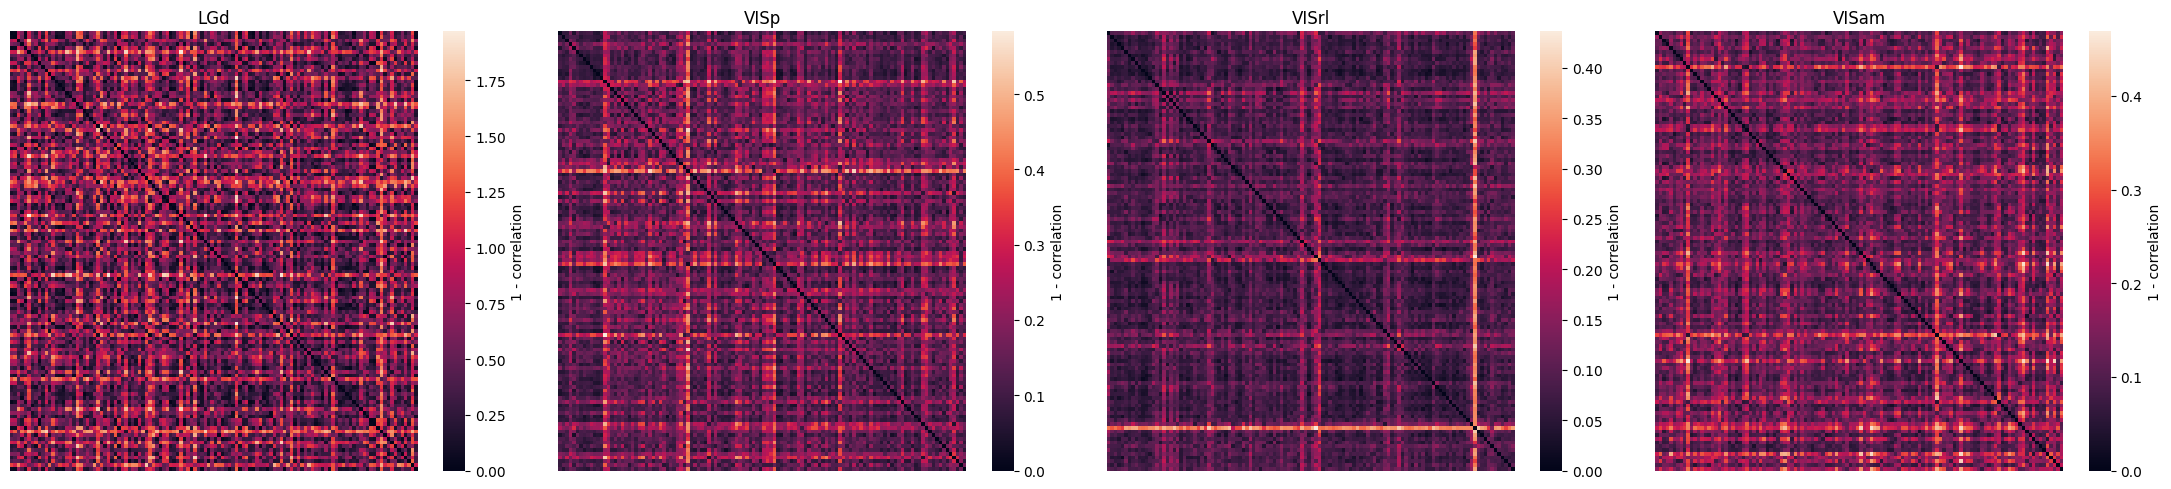

In [37]:
fig, axes = plt.subplots(1, len(AREAS), figsize=(5.5 * len(AREAS), 5))

for ax, area in zip(axes, AREAS):
    sns.heatmap(area_rdms[area], ax=ax, cbar_kws={"label": "1 - correlation"}, xticklabels=False, yticklabels=False)
    ax.set_title(area)
plt.tight_layout()
plt.show()

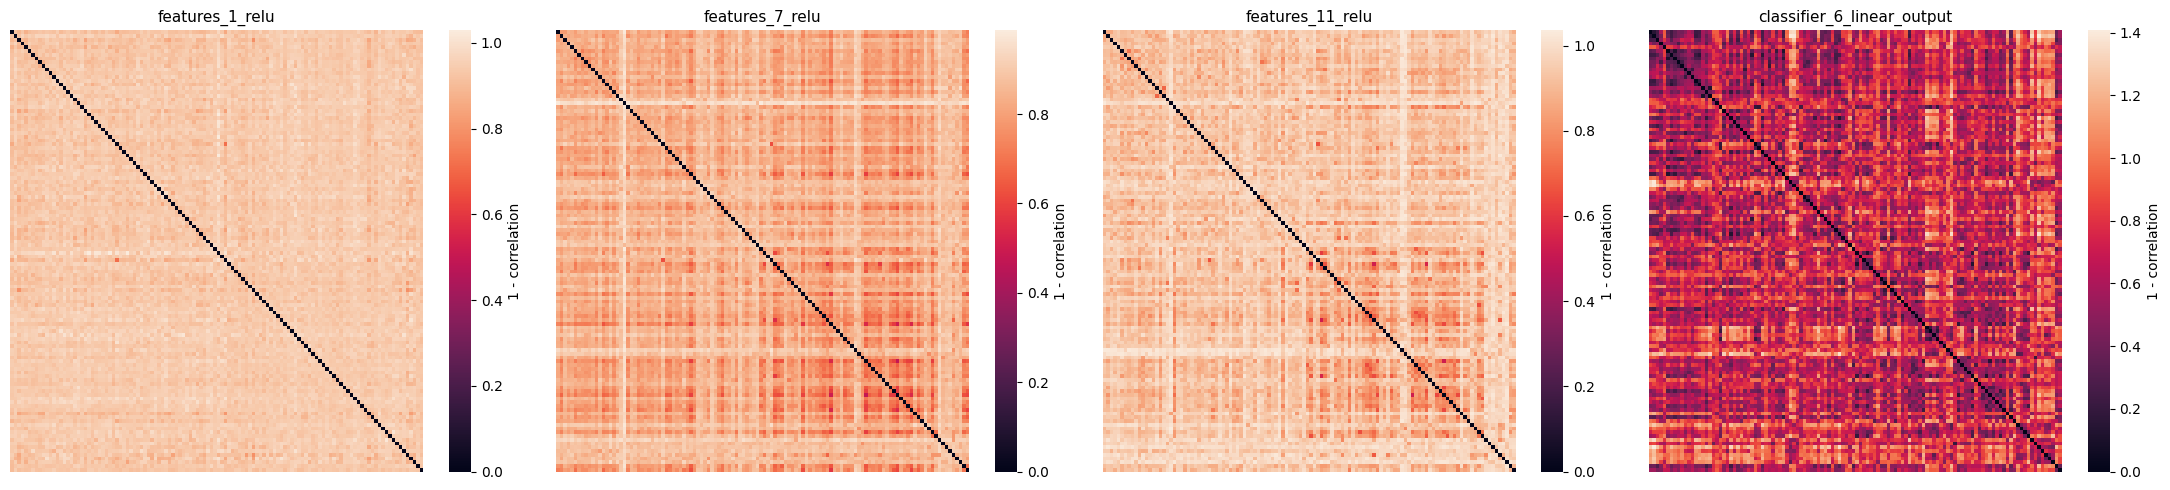

In [38]:
sample_layers = [layer_names[0], layer_names[2], layer_names[4], layer_names[-1]]
fig, axes = plt.subplots(1, len(sample_layers), figsize=(5.5 * len(sample_layers), 5))

for ax, layer in zip(axes, sample_layers):
    sns.heatmap(layer_rdms[layer], ax=ax, cbar_kws={"label": "1 - correlation"}, xticklabels=False, yticklabels=False)
    ax.set_title(layer, fontsize=11)

plt.tight_layout()
plt.show()

In [39]:
def upper_triangle(rdm):
    n = rdm.shape[0]
    iu = np.triu_indices(n, k=1)
    return rdm[iu]


def rsa(rdm_a, rdm_b):
    vec_a = upper_triangle(rdm_a)
    vec_b = upper_triangle(rdm_b)
    rho, _ = spearmanr(vec_a, vec_b)
    return rho

In [40]:
similarity = pd.DataFrame(index=layer_names, columns=AREAS, dtype=float)

In [41]:
similarity

,LGd,VISp,VISrl,VISam
features_1_relu,NaN,NaN,NaN,NaN
features_4_relu,NaN,NaN,NaN,NaN
features_7_relu,NaN,NaN,NaN,NaN
features_9_relu,NaN,NaN,NaN,NaN
features_11_relu,NaN,NaN,NaN,NaN
classifier_2_relu,NaN,NaN,NaN,NaN
classifier_5_relu,NaN,NaN,NaN,NaN
classifier_6_linear_output,NaN,NaN,NaN,NaN


In [42]:
area_names = list(neural_data["areas"].keys())

In [43]:
for layer in layer_names:
    for area in area_names:
        similarity.loc[layer, area] = rsa(layer_rdms[layer], area_rdms[area])

In [44]:
similarity

,LGd,VISp,VISrl,VISam
features_1_relu,0.037142,0.156725,0.146068,0.161546
features_4_relu,0.119759,0.192019,0.286629,0.075744
features_7_relu,0.109832,0.138934,0.293961,0.099236
features_9_relu,0.092689,0.094870,0.231480,0.108227
features_11_relu,0.078726,0.111313,0.209909,0.135551
classifier_2_relu,0.084813,0.103827,0.190149,0.135681
classifier_5_relu,0.081369,0.102165,0.161276,0.107867
classifier_6_linear_output,0.045171,0.054623,0.152629,0.103314


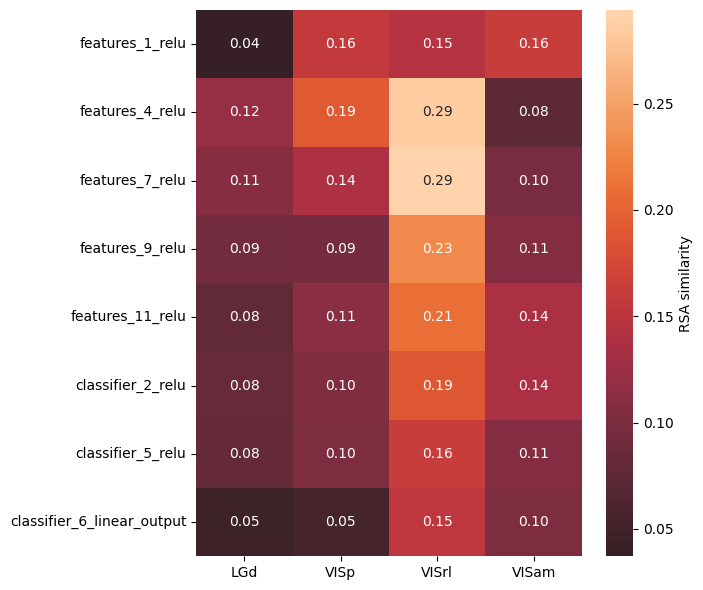

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(similarity.astype(float), annot=True, fmt=".2f", center=0, cbar_kws={"label": "RSA similarity"}, ax=ax, annot_kws={"size": 10}, linecolor="white")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

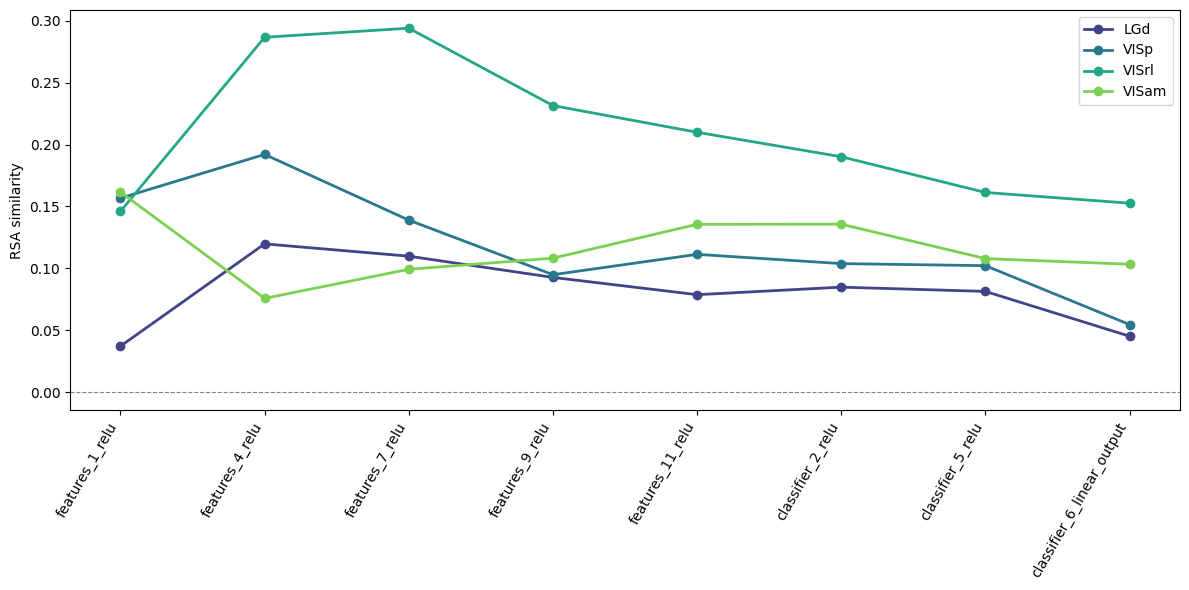

In [46]:
layer_positions = np.arange(8)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette("viridis", n_colors=len(area_names))
for area, color in zip(area_names, palette):
    ax.plot(layer_positions, similarity[area].values, marker="o", label=area, color=color, linewidth=2)

ax.legend()
ax.set_xticks(layer_positions)
ax.set_xticklabels(layer_names, rotation=60, ha="right")
ax.set_ylabel("RSA similarity")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

In [47]:
best_layer_per_area = similarity.idxmax(axis=0)
best_score_per_area = similarity.max(axis=0)

In [48]:
pd.DataFrame({"best_matching": best_layer_per_area, "similarity": best_score_per_area, "layer_depth_rank": [layer_names.index(l) for l in best_layer_per_area]})

,best_matching,similarity,layer_depth_rank
LGd,features_4_relu,0.119759,1
VISp,features_4_relu,0.192019,1
VISrl,features_7_relu,0.293961,2
VISam,features_1_relu,0.161546,0


In [49]:
torch.manual_seed(0)
np.random.seed(0)

In [50]:
image_names = alexnet_data["image_names"]
layer_names = list(alexnet_data["activations"].keys())
area_names = list(neural_data["areas"].keys())
N = len(image_names)

In [51]:
PCA_DIM = 32
EMBED_DIM = 32
VAL_FRACTION = 0.2
N_EPOCHS = 300
PATIENCE = 30
LR = 1e-3
WEIGHT_DECAY = 1e-3
TOP_K = 5

In [52]:
class Encoder(nn.Module):
    def __init__(self, in_dim, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, embed_dim * 2),
            nn.LayerNorm(embed_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(embed_dim * 2, embed_dim),
        )

    def forward(self, x):
        return self.net(x)


class NCPair(nn.Module):
    def __init__(self, network_in_dim, brain_in_dim, embed_dim):
        super().__init__()
        self.network_encoder = Encoder(network_in_dim, embed_dim)
        self.brain_encoder = Encoder(brain_in_dim, embed_dim)
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(0.07)))

    def forward(self, network_input, brain_input):
        net_embed = F.normalize(self.network_encoder(network_input), dim=-1)
        brain_embed = F.normalize(self.brain_encoder(brain_input), dim=-1)
        temperature = self.log_temperature.exp().clamp(min=0.01, max=1.0)
        logits = (net_embed @ brain_embed.T) / temperature
        return logits, net_embed, brain_embed


def clip_loss(logits):
    n = logits.shape[0]
    targets = torch.arange(n)
    loss_net_to_brain = F.cross_entropy(logits, targets)
    loss_brain_to_net = F.cross_entropy(logits.T, targets)
    return (loss_net_to_brain + loss_brain_to_net) / 2


def retrieval_accuracy(net_embed, brain_embed, k=1):
    n = net_embed.shape[0]
    sim = net_embed @ brain_embed.T
    targets = torch.arange(n)

    def topk_acc(similarity, targets, k):
        topk = similarity.topk(min(k, similarity.shape[1]), dim=1).indices
        correct = (topk == targets.unsqueeze(1)).any(dim=1)
        return correct.float().mean().item()

    return (topk_acc(sim, targets, k) + topk_acc(sim.T, targets, k)) / 2


In [53]:
def train_pair(layer, area, verbose=False):
    network_all = alexnet_data["activations"][layer]
    brain_all = neural_data["areas"][area]

    train_idx, val_idx = train_test_split(np.arange(N), test_size=VAL_FRACTION, random_state=0)

    n_components = min(PCA_DIM, len(train_idx) - 1)
    pca = PCA(n_components=n_components, random_state=0)
    network_train = pca.fit_transform(network_all[train_idx])
    network_val = pca.transform(network_all[val_idx])

    brain_train_raw = brain_all[train_idx]
    brain_val_raw = brain_all[val_idx]
    mean, std = brain_train_raw.mean(0, keepdims=True), brain_train_raw.std(0, keepdims=True) + 1e-6
    brain_train = (brain_train_raw - mean) / std
    brain_val = (brain_val_raw - mean) / std

    network_train_t = torch.tensor(network_train, dtype=torch.float32)
    network_val_t = torch.tensor(network_val, dtype=torch.float32)
    brain_train_t = torch.tensor(brain_train, dtype=torch.float32)
    brain_val_t = torch.tensor(brain_val, dtype=torch.float32)

    model = NCPair(network_in_dim=n_components, brain_in_dim=brain_train.shape[1], embed_dim=EMBED_DIM)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    train_losses, val_losses = [], []

    for epoch in range(N_EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits, _, _ = model(network_train_t, brain_train_t)
        loss = clip_loss(logits)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _, _ = model(network_val_t, brain_val_t)
            val_loss = clip_loss(val_logits).item()

        train_losses.append(loss.item())
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_logits, val_net_embed, val_brain_embed = model(network_val_t, brain_val_t)
        top1 = retrieval_accuracy(val_net_embed, val_brain_embed, k=1)
        top5 = retrieval_accuracy(val_net_embed, val_brain_embed, k=TOP_K)
        val_similarity = (val_net_embed @ val_brain_embed.T).numpy()

    if verbose:
        print(f"{layer} vs {area}: best_val_loss={best_val_loss}, top1={top1}, top5={top5}")

    return {
        "layer": layer, "area": area, "best_val_loss": best_val_loss,
        "top1": top1, "top5": top5, "n_val": len(val_idx),
        "train_losses": train_losses, "val_losses": val_losses,
        "val_similarity": val_similarity,
    }

In [56]:
DEMO_LAYER = "features_1_relu"
DEMO_AREA = "VISrl"

demo_result = train_pair(DEMO_LAYER, DEMO_AREA, verbose=True)

features_1_relu vs VISrl: best_val_loss=3.462794065475464, top1=0.0625, top5=0.3541666716337204


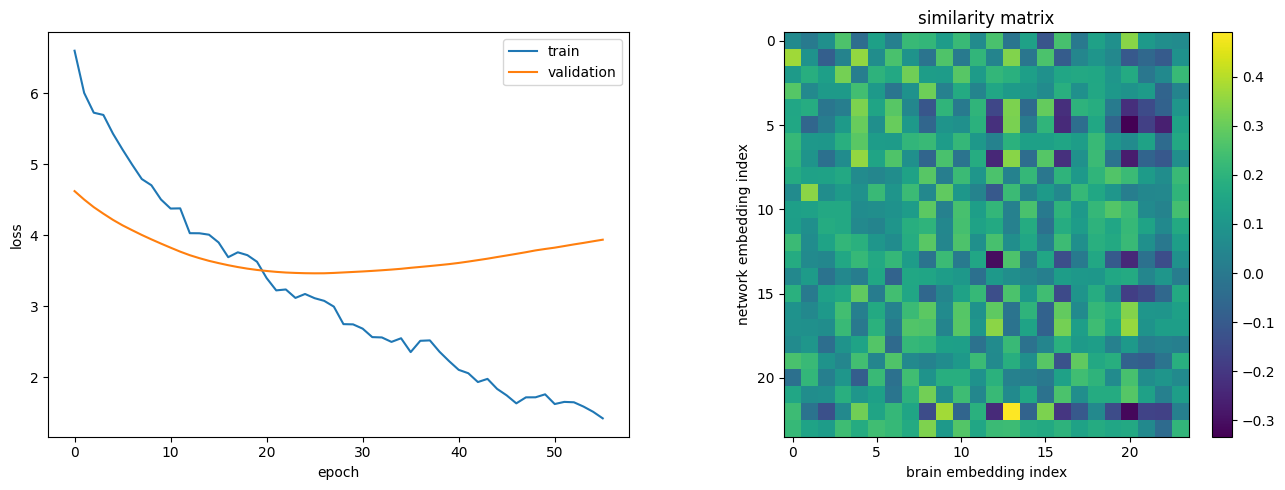

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(demo_result["train_losses"], label="train")
axes[0].plot(demo_result["val_losses"], label="validation")
n_train = N - demo_result["n_val"]
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

im = axes[1].imshow(demo_result["val_similarity"], cmap="viridis")
axes[1].set_xlabel("brain embedding index")
axes[1].set_ylabel("network embedding index")
axes[1].set_title("similarity matrix")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [59]:
all_results = []
for area in area_names:
    for layer in layer_names:
        result = train_pair(layer, area, verbose=True)
        all_results.append(result)

results_df = pd.DataFrame(all_results)[["layer", "area", "best_val_loss", "top1", "top5", "n_val"]]

features_1_relu vs LGd: best_val_loss=3.2046127319335938, top1=0.1041666679084301, top5=0.3541666567325592
features_4_relu vs LGd: best_val_loss=3.8008084297180176, top1=0.0416666679084301, top5=0.2708333283662796
features_7_relu vs LGd: best_val_loss=3.403933048248291, top1=0.0833333358168602, top5=0.375
features_9_relu vs LGd: best_val_loss=3.5909018516540527, top1=0.0416666679084301, top5=0.3125
features_11_relu vs LGd: best_val_loss=3.611640453338623, top1=0.06250000186264515, top5=0.2083333358168602
classifier_2_relu vs LGd: best_val_loss=3.210049629211426, top1=0.1041666679084301, top5=0.3333333283662796
classifier_5_relu vs LGd: best_val_loss=3.6130530834198, top1=0.0416666679084301, top5=0.1666666641831398
classifier_6_linear_output vs LGd: best_val_loss=3.7437198162078857, top1=0.0416666679084301, top5=0.2291666641831398
features_1_relu vs VISp: best_val_loss=3.2326622009277344, top1=0.10416666977107525, top5=0.5000000149011612
features_4_relu vs VISp: best_val_loss=3.49095606

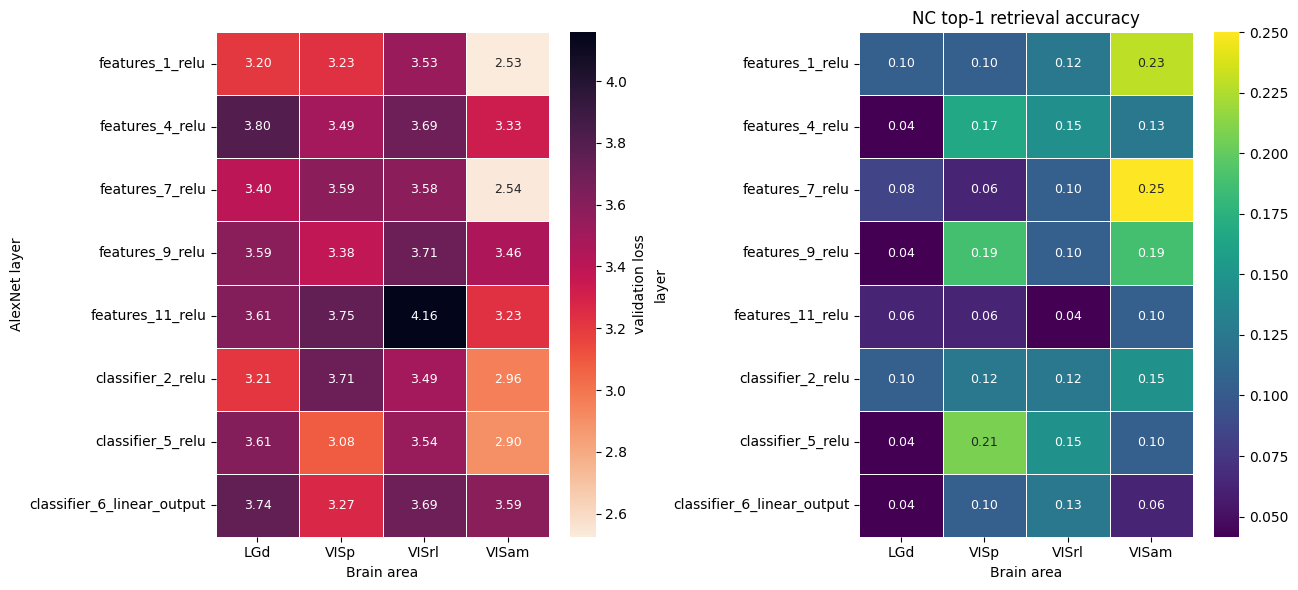

In [60]:
loss_pivot = results_df.pivot(index="layer", columns="area", values="best_val_loss").loc[layer_names, area_names]
top1_pivot = results_df.pivot(index="layer", columns="area", values="top1").loc[layer_names, area_names]

fig, axes = plt.subplots(1, 2, figsize=(13, max(6, 0.45 * len(layer_names))))

sns.heatmap(loss_pivot, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[0],
            annot_kws={"size": 9}, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "validation loss"})

axes[0].set_xlabel("Brain area")
axes[0].set_ylabel("AlexNet layer")

sns.heatmap(top1_pivot, annot=True, fmt=".2f", cmap="viridis", ax=axes[1],
            annot_kws={"size": 9}, linewidths=0.5, linecolor="white")
axes[1].set_title("NC top-1 retrieval accuracy")
axes[1].set_xlabel("Brain area")

plt.tight_layout()
plt.show()